# Envrionment

In [1]:
%load_ext autoreload
%autoreload 2

In [26]:
import os
from pathlib import Path
os.chdir('/Users/burkelawlor/Repos/hci-irae')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as sd
import scanpy as sc
import squidpy as sq
import anndata as ad
from spatialdata_io import xenium

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

from utils.processing import propogate_subset_labels, get_ranked_genes_by_group
from utils.plotting import feature_plots_from_marker_genes, spatial_plot_cell_types_individual, spatial_plot_cell_types_layered, plot_proportions_bar
from utils.diffex import run_diffex, plot_volcano

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load data

In [4]:
adata_rmc = ad.read_h5ad("./data/adata/rmc_annotated_5_detailed.h5ad")

adata_immune = adata_rmc[adata_rmc.obs['ct_immune'].notna().copy()]

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
sample_list = adata_rmc.obs['sample_name'].unique().to_list()
print(sample_list)

nl_samples = ['NS1', 'NS2','NS3','NS4']
rmc_epd_samples = ['EPD1', 'EPD2','EPD3','EPD4','EPD5','EPD6','EPD7']
nl_epd_samples = ['EPD8','EPD9','EPD10']
pnt_samples = ['PNT1','PNT2']

sample_name_to_condition = {}
for s in nl_samples:
    sample_name_to_condition[s] = 'NL'
for s in rmc_epd_samples:
    sample_name_to_condition[s] = 'RMC_EPD'
for s in nl_epd_samples:
    sample_name_to_condition[s] = 'NL_EPD'
for s in pnt_samples:
    sample_name_to_condition[s] = 'PNT'

adata_rmc.obs['sample_set_2'] = adata_rmc.obs['sample_name'].map(sample_name_to_condition)

['PNT1', 'PNT2', 'EPD1', 'EPD2', 'EPD3', 'EPD4', 'EPD5', 'EPD6', 'EPD7', 'NS1', 'NS2', 'NS3', 'NS4', 'EPD8', 'EPD9', 'EPD10']


# Differential expression analysis

In [72]:
all_results = {}

## Normal vs RMC EPD

In [73]:
adata_subset = adata_rmc[adata_rmc.obs['sample_set_2'].isin(['NL','RMC_EPD'])].copy()
adata_subset.obs['condition'] = adata_subset.obs['sample_set_2'].astype('category')

sample_col   = 'sample_name'
celltype_col = 'ct_detailed'
condition_col = 'condition'
contrast     = (condition_col, 'RMC_EPD', 'NL')

# Pseudobulk per (sample x cell type); design: ~ condition (between-subject)
results = run_diffex(
    adata_subset,
    sample_col=sample_col,
    celltype_col=celltype_col,
    condition_col=condition_col,
    contrast=contrast,
)


# Make one dataframe of results
df_list = []
for ct, df in results.items():
    df_ct = df.copy()
    df_ct.insert(0, 'ct', ct)
    df_list.append(df_ct)

results_df = pd.concat(df_list, ignore_index=True)
results_df['sig'] = results_df['padj'] < 0.05
results_df['direction'] = np.where(results_df['log2FoldChange'] > 0, 'up', 'down')
results_df.head()

all_results[contrast] = results_df

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[SKIP] B cells: only one condition represented
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 12 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.14 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition RMC_EPD vs NL
           baseMean  log2FoldChange     lfcSE      stat        pvalue      padj
A2ML1    390.420577        4.552198  0.856073  5.317535  1.051824e-07  0.000002
AAMP     598.791960       -0.031645  0.126146 -0.250863  8.019198e-01  0.874238
AAR2     133.989650        0.061700  0.194658  0.316967  7.512687e-01  0.836112
AARSD1   220.838764        0.750930  0.183649  4.088949  4.333321e-05  0.000338
ABAT      27.756272       -0.392018  0.353677 -1.108408  2.676855e-01  0.405081
...             ...             ...       ...       ...           ...       ...
ZSCAN26   91.948249       -0.530181  0.200539 -2.643788  8.198390e-03  0.026464
ZSWIM6    69.271263        0.832155  0.233750  3.560021  3.708257e-04  0.002023
ZUP1     150.047874        0.224826  0.157495  1.427514  1.534319e-01  0.267381
ZYG11B   128.262574       -0.727925  0.154104 -4.723598  2.317082e-06  0.000030
ZYX      712.418964        1.039344  0.329077  3.158362  1

Fitting dispersions...
... done in 0.17 seconds.

Fitting dispersion trend curve...
/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 1 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.14 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


...

Fitting dispersions...
... done in 0.16 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 1 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.22 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition RMC_EPD vs NL
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     1.260481        1.947204  1.891425  1.029490  0.303249       NaN
AAMP     14.680130        0.577387  0.380781  1.516322  0.129438  0.517933
AAR2      5.517918        0.178326  0.597618  0.298395  0.765402  0.944095
AARSD1    6.474235        0.139472  0.519290  0.268582  0.788251  0.948805
ABAT      6.026671        0.952420  0.611050  1.558662  0.119076  0.498862
...            ...             ...       ...       ...       ...       ...
ZSCAN26   6.249808       -0.421354  0.517855 -0.813652  0.415844  0.786219
ZSWIM6    1.646471        1.213419  1.299402  0.933829  0.350392       NaN
ZUP1      6.552557        0.600591  0.536636  1.119178  0.263064  0.661836
ZYG11B    5.316175       -0.204287  0.545552 -0.374459  0.708063  0.929638
ZYX      70.585247        0.025541  0.201997  0.126443  0.899381  0.977871

[5001 rows x 6 columns]
[OK] Tregs: 1

... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 4 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...


Log2 fold change & Wald test p-value: condition RMC_EPD vs NL
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1      1.261864        1.136831  1.073281  1.059210  0.289504       NaN
AAMP     101.855378       -0.067933  0.142931 -0.475286  0.634583  0.780617
AAR2      45.024472        0.400395  0.257119  1.557238  0.119414  0.272770
AARSD1    46.297671        0.197942  0.192276  1.029470  0.303259  0.497449
ABAT       8.306941        0.285564  0.501519  0.569398  0.569086  0.728659
...             ...             ...       ...       ...       ...       ...
ZSCAN26   41.044902       -0.435953  0.262037 -1.663711  0.096170  0.235315
ZSWIM6    23.577949        0.243282  0.351753  0.691628  0.489171  0.669871
ZUP1      31.447336       -0.032729  0.233905 -0.139925  0.888719  0.942124
ZYG11B    46.400372       -0.322039  0.190723 -1.688513  0.091313  0.227360
ZYX      192.872044        0.409325  0.215841  1.896422  0.057904  0.166149

[5001 rows x 6 columns]
[

... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.14 seconds.



In [74]:
nonimmune_cts = adata_rmc.obs[adata_rmc.obs['ct_general'] != 'Immune']['ct_detailed'].unique().to_list()
nonimmune_results = results_df[results_df['ct'].isin(nonimmune_cts)]

missing_nonimmune_cts = [ct for ct in nonimmune_cts if ct not in nonimmune_results['ct'].unique()]
print("Non-immune cell types included in nonimmune_results['ct']:", ", ".join(nonimmune_results['ct'].unique()))
print("Non-immune cell types not in nonimmune_results['ct']:", ", ".join(missing_nonimmune_cts))
print()

immune_cts = adata_rmc.obs[adata_rmc.obs['ct_general'] == 'Immune']['ct_detailed'].unique().to_list()
immune_results = results_df[results_df['ct'].isin(immune_cts)]

missing_immune_cts = [ct for ct in immune_cts if ct not in immune_results['ct'].unique()]
print("Immune cell types included in immune_results['ct']:", ", ".join(immune_results['ct'].unique()))
print("Immune cell types not in immune_results['ct']:", ", ".join(missing_immune_cts))


Non-immune cell types included in nonimmune_results['ct']: Basal KCs, Fibroblasts, Granular KCs, Lymphatic ECs, Melanocytes, Pericytes, Sebocytes, Spinous KCs, Sweat duct, Vascular ECs
Non-immune cell types not in nonimmune_results['ct']: Unknown/dead

Immune cell types included in immune_results['ct']: CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLEC9A+ DCs, Langerhans, Macrophages, Mast cells, Tregs
Immune cell types not in immune_results['ct']: Plasma cells, Innate lymphocytes, LAMP3+ DCs, B cells, Plasmacytoid DC, Neutrophils


In [75]:
# sig_by_ct = results_df.groupby('ct').agg({'sig': 'sum'}).sort_values('sig', ascending=False)
# display(sig_by_ct)

# sig_by_ct.to_csv('./output/sig_by_ct_immune_NL_vs_RMC_EPD.csv')

In [76]:
sig_by_gene = immune_results.groupby('gene').agg({'sig': 'sum'}).sort_values('sig', ascending=False)
sig_by_gene['sig_cell_types'] = sig_by_gene.index.map(
    lambda gene: immune_results[(immune_results['gene'] == gene) & (immune_results['sig'])]['ct'].unique().tolist()
)

display(sig_by_gene[sig_by_gene['sig'] > 1])

sig_by_gene.to_csv('./output/sig_by_gene_immune_NL_vs_RMC_EPD.csv')

,sig,sig_cell_types
gene,,
DIO2,7,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLE..."
JAK3,7,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLE..."
CD14,7,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, Lan..."
CFH,6,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, Mac..."
HIF1A,6,"[CD4+ T cells, CLEC10A+ DCs, Langerhans, Macro..."
...,...,...
ITGB2,2,"[Langerhans, Macrophages]"
LAG3,2,"[CD8+ T cells, Tregs]"
NPAT,2,"[CLEC10A+ DCs, Tregs]"


In [77]:
# # Top significant genes per cell type
# for ct, df in results.items():
#     sig = df[df['padj'] < 0.05]
#     print(f'=== {ct} ({len(sig)} significant genes) ===')
#     print(sig[['gene', 'log2FoldChange', 'padj']].head(20).to_string())


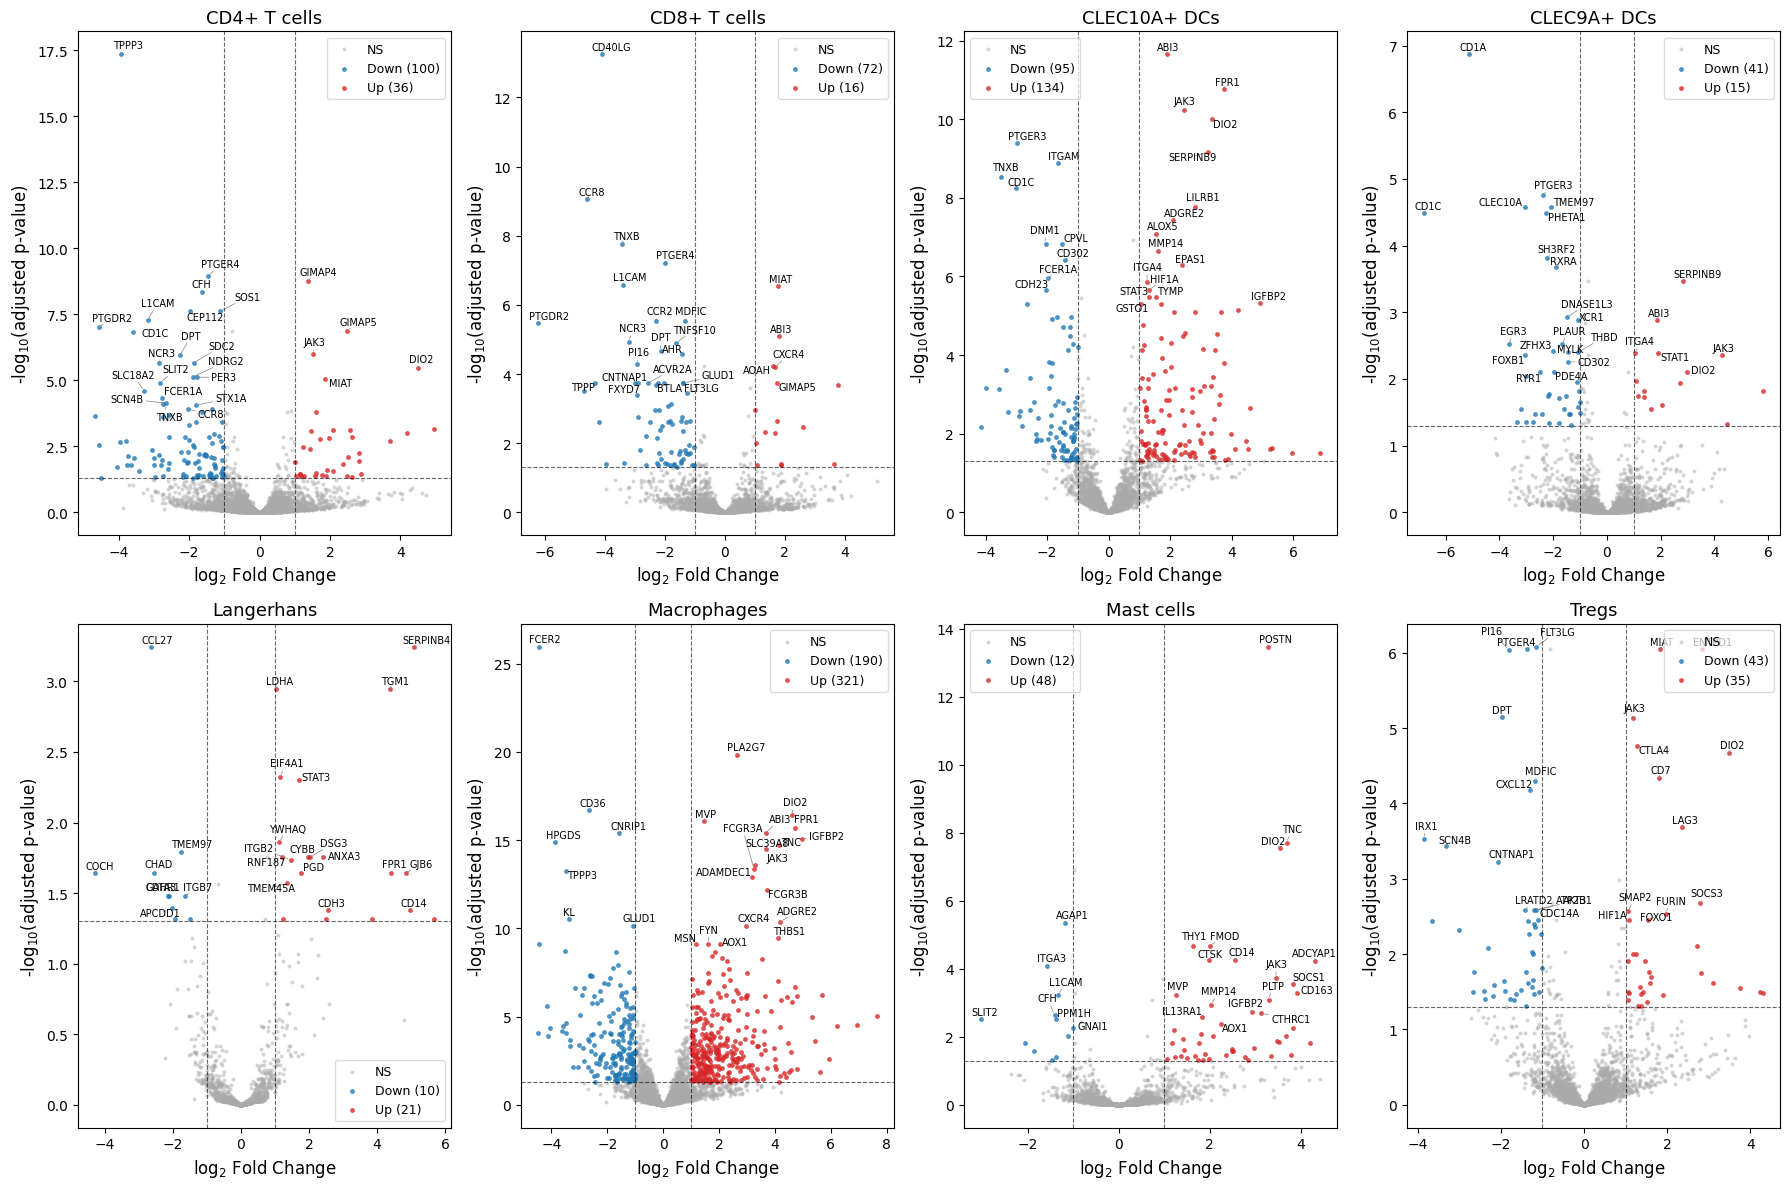

In [78]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for i, ct in enumerate(immune_results['ct'].unique()):
    fig = plot_volcano(immune_results[immune_results['ct'] == ct], title=ct, top_n_labels=25, ax=axes[i])

plt.show()

## Normal vs Normal EPD

In [79]:
adata_subset = adata_rmc[adata_rmc.obs['sample_set_2'].isin(['NL','NL_EPD'])].copy()
adata_subset.obs['condition'] = adata_subset.obs['sample_set_2'].astype('category')

sample_col   = 'sample_name'
celltype_col = 'ct_detailed'
condition_col = 'condition'
contrast     = (condition_col, 'NL_EPD', 'NL')

# Pseudobulk per (sample x cell type); design: ~ condition (between-subject)
results = run_diffex(
    adata_subset,
    sample_col=sample_col,
    celltype_col=celltype_col,
    condition_col=condition_col,
    contrast=contrast,
)

# Make one dataframe of results
df_list = []
for ct, df in results.items():
    df_ct = df.copy()
    df_ct.insert(0, 'ct', ct)
    df_list.append(df_ct)

results_df = pd.concat(df_list, ignore_index=True)
results_df['sig'] = results_df['padj'] < 0.05
results_df['direction'] = np.where(results_df['log2FoldChange'] > 0, 'up', 'down')
results_df.head()

all_results[contrast] = results_df

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[SKIP] B cells: only 3 pseudobulk samples (need 4)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition NL_EPD vs NL
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     44.776336        1.744770  0.624239  2.795033  0.005189  0.019554
AAMP     499.000800       -0.218288  0.181333 -1.203797  0.228668  0.378327
AAR2     115.572859        0.033707  0.273597  0.123198  0.901950  0.937592
AARSD1   143.761087        0.207760  0.287214  0.723363  0.469457  0.616712
ABAT      34.224738        0.513627  0.382972  1.341163  0.179868  0.318629
...             ...             ...       ...       ...       ...       ...
ZSCAN26   82.393892       -0.724199  0.299901 -2.414796  0.015744  0.047571
ZSWIM6    47.480455        0.476518  0.424052  1.123726  0.261129  0.413504
ZUP1     119.963513        0.018568  0.234016  0.079346  0.936757  0.960022
ZYG11B   131.260855       -0.542648  0.235200 -2.307175  0.021045  0.060546
ZYX      535.103273        1.004789  0.281653  3.567472  0.000360  0.002050

[5001 rows x 6 columns]
[O

Fitting dispersions...
... done in 0.21 seconds.

Fitting dispersion trend curve...
/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


...

Fitting dispersions...
... done in 0.17 seconds.

Fitting dispersion trend curve...
/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition NL_EPD vs NL
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     0.459337        0.900637  1.640110  0.549132  0.582915       NaN
AAMP     18.077308        0.572432  0.402489  1.422229  0.154960  0.665638
AAR2      8.265478        0.436678  0.559357  0.780679  0.434992  0.870259
AARSD1    7.703061       -0.142628  0.534574 -0.266807  0.789618  0.976511
ABAT      7.334847        0.858911  0.658683  1.303983  0.192239  0.707082
...            ...             ...       ...       ...       ...       ...
ZSCAN26   8.336773       -0.534463  0.551606 -0.968923  0.332584  0.812249
ZSWIM6    1.458318        0.869507  1.111807  0.782066  0.434176       NaN
ZUP1      8.987193        0.891919  0.577624  1.544117  0.122560  0.613771
ZYG11B    7.524229       -0.129774  0.567227 -0.228787  0.819034  0.981716
ZYX      90.237863       -0.273439  0.369349 -0.740327  0.459101  0.885437

[5001 rows x 6 columns]
[OK] Tregs: 83

Fitting dispersions...
... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: condition NL_EPD vs NL
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1      1.804785        1.277568  1.268478  1.007166  0.313855       NaN
AAMP     149.140457       -0.157170  0.175435 -0.895887  0.370313  0.584819
AAR2      59.864032        0.343859  0.270265  1.272302  0.203266  0.406025
AARSD1    58.675473       -0.196715  0.243422 -0.808122  0.419020  0.629630
ABAT      12.132143        0.387227  0.524002  0.738980  0.459919  0.664908
...             ...             ...       ...       ...       ...       ...
ZSCAN26   61.587457       -0.607869  0.340905 -1.783102  0.074570  0.209202
ZSWIM6    35.582716        0.374298  0.380000  0.984994  0.324627  0.541445
ZUP1      47.329268       -0.062926  0.276002 -0.227990  0.819654  0.909066
ZYG11B    78.126357       -0.044136  0.260531 -0.169408  0.865475  0.932963
ZYX      284.386044        0.600527  0.259884  2.310748  0.020847  0.084761

[5001 rows x 6 columns]
[O

... done in 0.17 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.15 seconds.



In [80]:
nonimmune_cts = adata_rmc.obs[adata_rmc.obs['ct_general'] != 'Immune']['ct_detailed'].unique().to_list()
nonimmune_results = results_df[results_df['ct'].isin(nonimmune_cts)]

missing_nonimmune_cts = [ct for ct in nonimmune_cts if ct not in nonimmune_results['ct'].unique()]
print("Non-immune cell types included in nonimmune_results['ct']:", ", ".join(nonimmune_results['ct'].unique()))
print("Non-immune cell types not in nonimmune_results['ct']:", ", ".join(missing_nonimmune_cts))
print()

immune_cts = adata_rmc.obs[adata_rmc.obs['ct_general'] == 'Immune']['ct_detailed'].unique().to_list()
immune_results = results_df[results_df['ct'].isin(immune_cts)]

missing_immune_cts = [ct for ct in immune_cts if ct not in immune_results['ct'].unique()]
print("Immune cell types included in immune_results['ct']:", ", ".join(immune_results['ct'].unique()))
print("Immune cell types not in immune_results['ct']:", ", ".join(missing_immune_cts))


Non-immune cell types included in nonimmune_results['ct']: Basal KCs, Fibroblasts, Granular KCs, Lymphatic ECs, Melanocytes, Pericytes, Sebocytes, Spinous KCs, Sweat duct, Vascular ECs
Non-immune cell types not in nonimmune_results['ct']: Unknown/dead

Immune cell types included in immune_results['ct']: CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLEC9A+ DCs, Langerhans, Macrophages, Mast cells, Tregs
Immune cell types not in immune_results['ct']: Plasma cells, Innate lymphocytes, LAMP3+ DCs, B cells, Plasmacytoid DC, Neutrophils


In [81]:
sig_by_gene = immune_results.groupby('gene').agg({'sig': 'sum'}).sort_values('sig', ascending=False)
sig_by_gene['sig_cell_types'] = sig_by_gene.index.map(
    lambda gene: immune_results[(immune_results['gene'] == gene) & (immune_results['sig'])]['ct'].unique().tolist()
)

display(sig_by_gene[sig_by_gene['sig'] > 1])

sig_by_gene.to_csv('./output/sig_by_gene_immune_NL_vs_NL_EPD.csv')

,sig,sig_cell_types
gene,,
POSTN,7,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, Lan..."
TNXB,7,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLE..."
DIO2,7,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLE..."
STAT1,7,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLE..."
IRF1,7,"[CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLE..."
...,...,...
TLR8,2,"[CLEC9A+ DCs, Macrophages]"
ITGAX,2,"[CLEC9A+ DCs, Macrophages]"
ITGA3,2,"[CLEC10A+ DCs, Mast cells]"


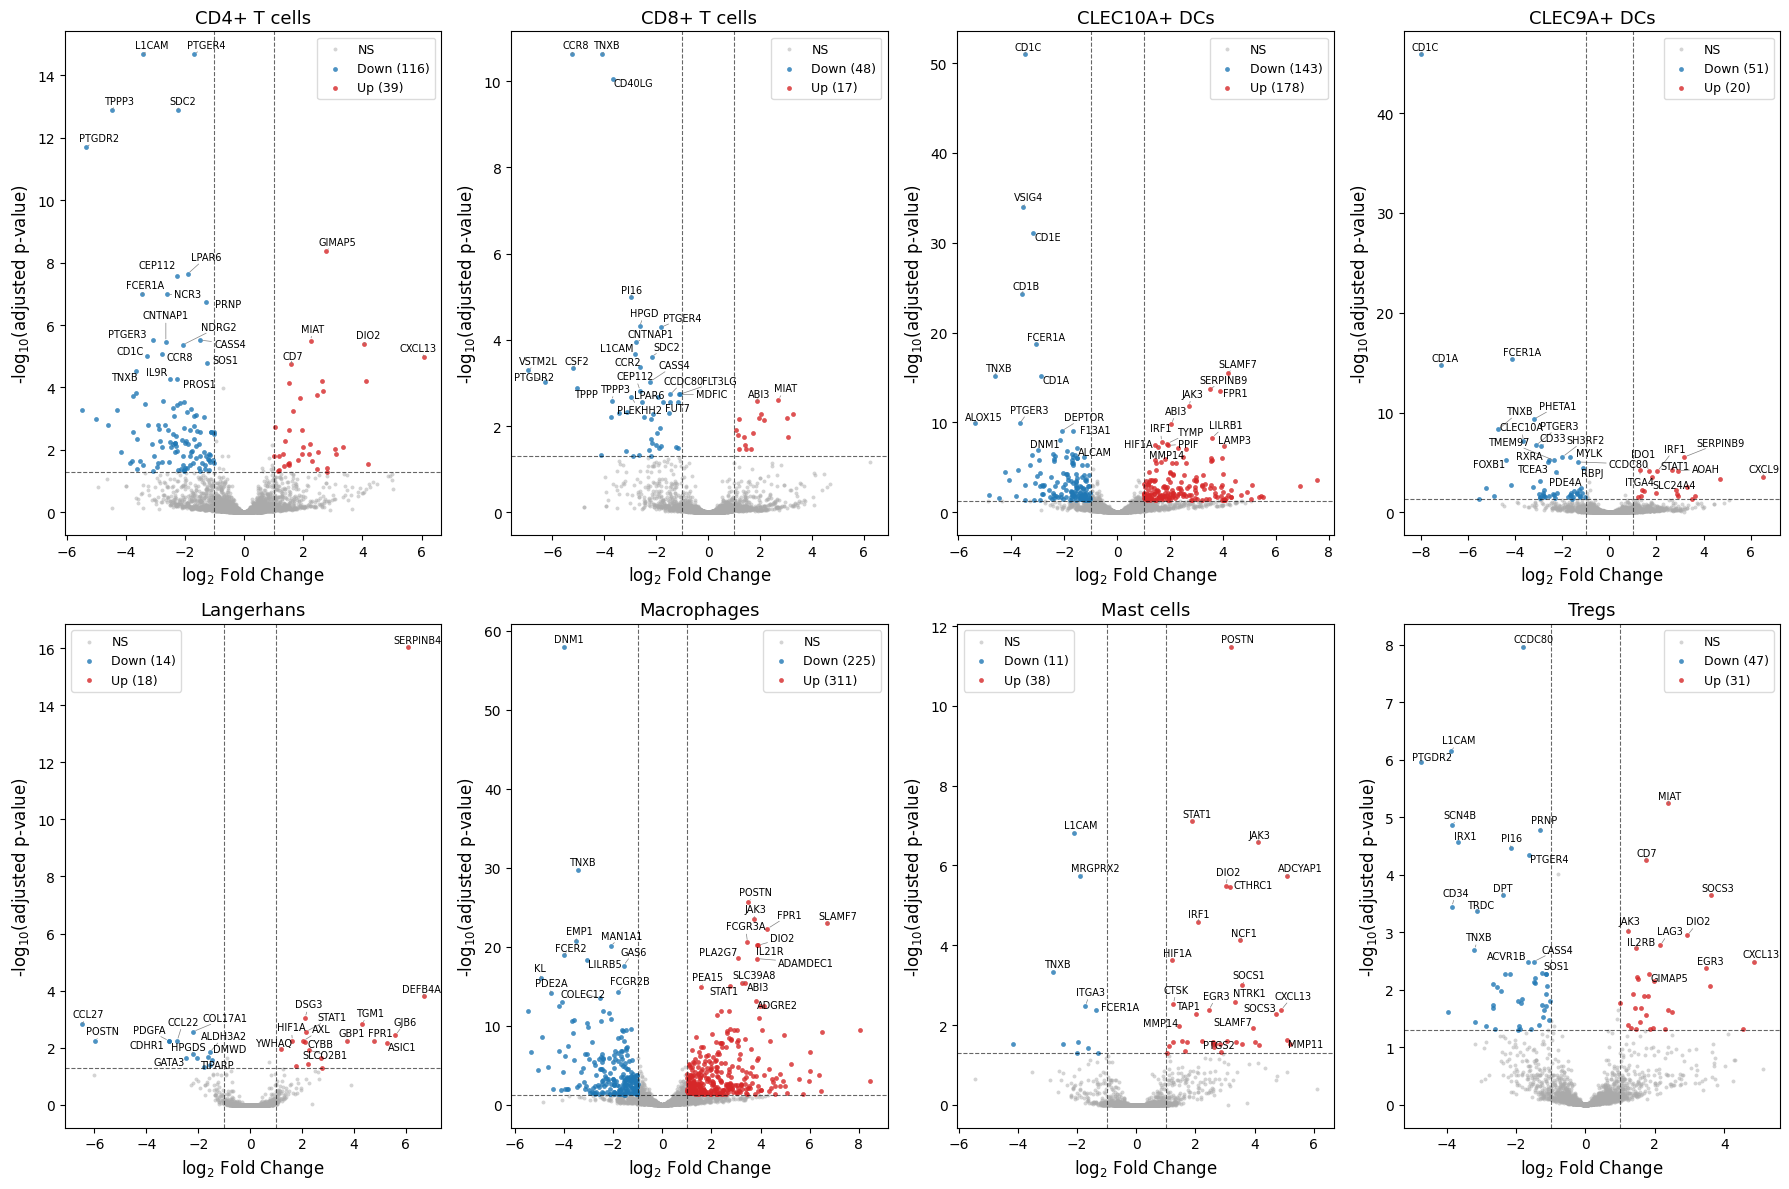

In [82]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for i, ct in enumerate(immune_results['ct'].unique()):
    fig = plot_volcano(immune_results[immune_results['ct'] == ct], title=ct, top_n_labels=25, ax=axes[i])

plt.show()

## Normal vs PNT

In [83]:
adata_subset = adata_rmc[adata_rmc.obs['sample_set_2'].isin(['NL','PNT'])].copy()
adata_subset.obs['condition'] = adata_subset.obs['sample_set_2'].astype('category')

sample_col   = 'sample_name'
celltype_col = 'ct_detailed'
condition_col = 'condition'
contrast     = (condition_col, 'PNT', 'NL')

# Pseudobulk per (sample x cell type); design: ~ condition (between-subject)
results = run_diffex(
    adata_subset,
    sample_col=sample_col,
    celltype_col=celltype_col,
    condition_col=condition_col,
    contrast=contrast,
)

# Make one dataframe of results
df_list = []
for ct, df in results.items():
    df_ct = df.copy()
    df_ct.insert(0, 'ct', ct)
    df_list.append(df_ct)

results_df = pd.concat(df_list, ignore_index=True)
results_df['sig'] = results_df['padj'] < 0.05
results_df['direction'] = np.where(results_df['log2FoldChange'] > 0, 'up', 'down')
results_df.head()

all_results[contrast] = results_df

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[SKIP] B cells: only 2 pseudobulk samples (need 4)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition PNT vs NL
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     20.007801        1.057318  0.710922  1.487248  0.136949  0.366384
AAMP     340.774797       -0.115046  0.201115 -0.572042  0.567294  0.788358
AAR2      76.084816        0.066136  0.307961  0.214756  0.829958  0.921824
AARSD1   107.161520        0.697711  0.280495  2.487429  0.012867  0.080179
ABAT      17.841167       -0.271985  0.554534 -0.490475  0.623798  0.821256
...             ...             ...       ...       ...       ...       ...
ZSCAN26   66.074197        0.045879  0.355122  0.129192  0.897206  0.954831
ZSWIM6    31.232518        0.553944  0.486139  1.139476  0.254505  0.523356
ZUP1      82.120970        0.174535  0.292747  0.596198  0.551043  0.776943
ZYG11B    83.720810       -0.940449  0.306653 -3.066820  0.002163  0.021898
ZYX      311.623979        0.850659  0.212989  3.993904  0.000065  0.001423

[5001 rows x 6 columns]
[OK] 

... done in 0.16 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.14 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.13 seconds.

Fitting size factors...
... done in 0.00 seconds.



...

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.20 seconds.

Fitting dispersion trend curve...
/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.15 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition PNT vs NL
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     0.147283        1.325372  3.597696  0.368395  0.712579  0.999578
AAMP      6.047430        0.838913  0.788062  1.064527  0.287090  0.999578
AAR2      2.055994       -0.663198  1.189121 -0.557721  0.577035  0.999578
AARSD1    2.703935        0.266373  1.037351  0.256782  0.797347  0.999578
ABAT      2.659845        1.294491  1.033427  1.252619  0.210344  0.999578
...            ...             ...       ...       ...       ...       ...
ZSCAN26   2.623708       -0.499204  1.169946 -0.426690  0.669605  0.999578
ZSWIM6    0.743468        2.120149  2.634179  0.804861  0.420900  0.999578
ZUP1      2.631277        1.005049  1.080016  0.930586  0.352068  0.999578
ZYG11B    2.963430        0.721874  1.050965  0.686867  0.492166  0.999578
ZYX      30.774756       -0.051865  0.451147 -0.114962  0.908476  0.999578

[5001 rows x 6 columns]
[OK] Tregs: 0 sig

... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: condition PNT vs NL
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1      0.378817       -1.492388  3.842483 -0.388392  0.697726       NaN
AAMP      92.346370       -0.026345  0.263895 -0.099832  0.920478  0.980404
AAR2      32.010359        0.060796  0.410094  0.148249  0.882146  0.971050
AARSD1    41.324742        0.437584  0.357067  1.225495  0.220389  0.586578
ABAT       7.099793        0.432382  0.835580  0.517463  0.604833  0.864281
...             ...             ...       ...       ...       ...       ...
ZSCAN26   43.685963        0.075699  0.433033  0.174810  0.861229  0.965628
ZSWIM6    18.816181        0.082355  0.573225  0.143669  0.885762  0.971050
ZUP1      30.870949        0.288557  0.415167  0.695039  0.487031  0.799482
ZYG11B    44.861636       -0.228803  0.374255 -0.611356  0.540964  0.830613
ZYX      167.462614        0.687219  0.234146  2.934999  0.003335  0.048747

[5001 rows x 6 columns]
[OK] 

... done in 0.28 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.15 seconds.



In [84]:
nonimmune_cts = adata_rmc.obs[adata_rmc.obs['ct_general'] != 'Immune']['ct_detailed'].unique().to_list()
nonimmune_results = results_df[results_df['ct'].isin(nonimmune_cts)]

missing_nonimmune_cts = [ct for ct in nonimmune_cts if ct not in nonimmune_results['ct'].unique()]
print("Non-immune cell types included in nonimmune_results['ct']:", ", ".join(nonimmune_results['ct'].unique()))
print("Non-immune cell types not in nonimmune_results['ct']:", ", ".join(missing_nonimmune_cts))
print()

immune_cts = adata_rmc.obs[adata_rmc.obs['ct_general'] == 'Immune']['ct_detailed'].unique().to_list()
immune_results = results_df[results_df['ct'].isin(immune_cts)]

missing_immune_cts = [ct for ct in immune_cts if ct not in immune_results['ct'].unique()]
print("Immune cell types included in immune_results['ct']:", ", ".join(immune_results['ct'].unique()))
print("Immune cell types not in immune_results['ct']:", ", ".join(missing_immune_cts))


Non-immune cell types included in nonimmune_results['ct']: Basal KCs, Fibroblasts, Granular KCs, Lymphatic ECs, Melanocytes, Pericytes, Sebocytes, Spinous KCs, Sweat duct, Vascular ECs
Non-immune cell types not in nonimmune_results['ct']: Unknown/dead

Immune cell types included in immune_results['ct']: CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLEC9A+ DCs, Macrophages, Mast cells, Tregs
Immune cell types not in immune_results['ct']: Plasma cells, Innate lymphocytes, LAMP3+ DCs, B cells, Plasmacytoid DC, Langerhans, Neutrophils


In [85]:
sig_by_gene = immune_results.groupby('gene').agg({'sig': 'sum'}).sort_values('sig', ascending=False)
sig_by_gene['sig_cell_types'] = sig_by_gene.index.map(
    lambda gene: immune_results[(immune_results['gene'] == gene) & (immune_results['sig'])]['ct'].unique().tolist()
)

display(sig_by_gene[sig_by_gene['sig'] > 1])
print(len(sig_by_gene[sig_by_gene['sig'] > 1]))

sig_by_gene.to_csv('./output/sig_by_gene_immune_NL_vs_PNT.csv')

,sig,sig_cell_types
gene,,
JAK3,4,"[CD4+ T cells, CLEC10A+ DCs, Macrophages, Mast..."
CD1C,3,"[CLEC10A+ DCs, CLEC9A+ DCs, Macrophages]"
SLC40A1,3,"[CD4+ T cells, CLEC10A+ DCs, Macrophages]"
HOXB7,3,"[CD4+ T cells, CLEC10A+ DCs, Macrophages]"
FCER1A,3,"[CD4+ T cells, CLEC10A+ DCs, Macrophages]"
MVP,3,"[CD4+ T cells, CLEC10A+ DCs, Macrophages]"
CTSL,2,"[CD4+ T cells, Macrophages]"
P4HB,2,"[CLEC10A+ DCs, Macrophages]"
P2RY14,2,"[CLEC10A+ DCs, Macrophages]"


49


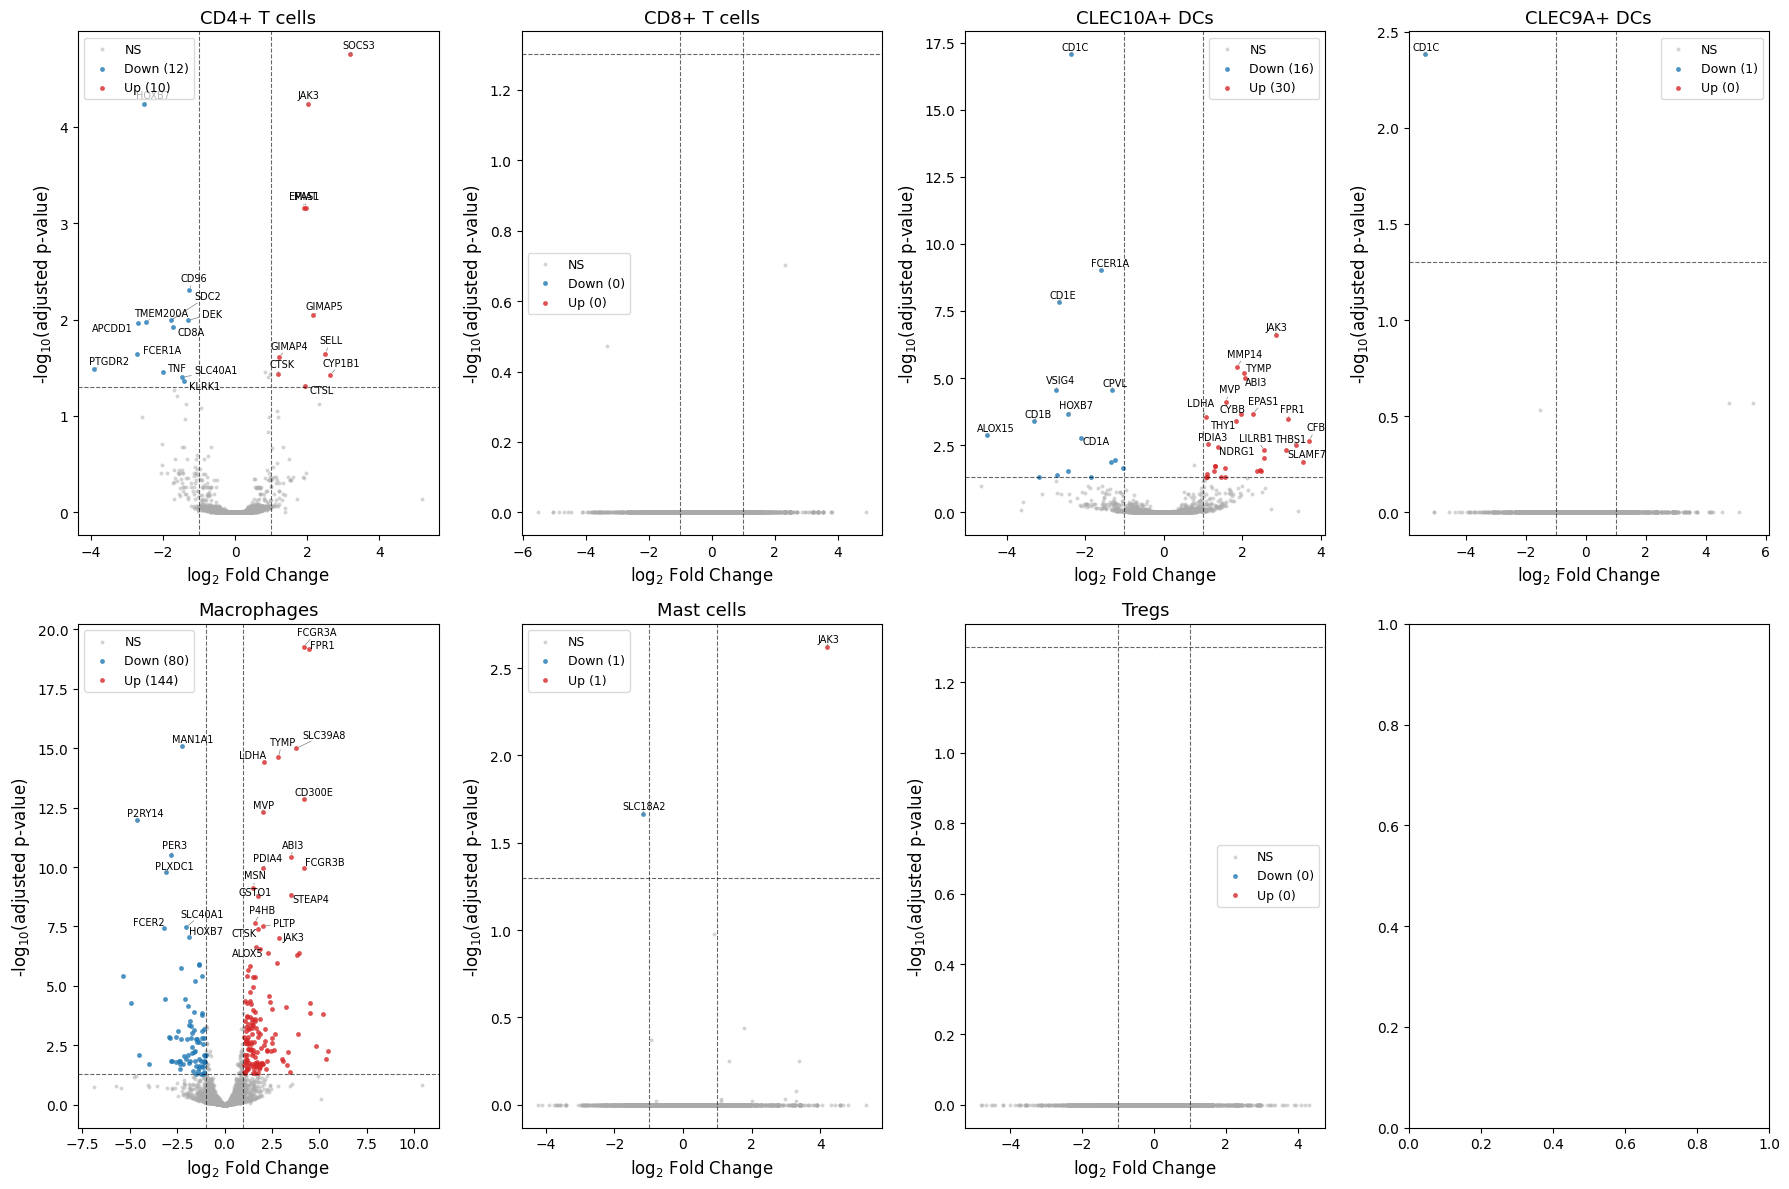

In [86]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for i, ct in enumerate(immune_results['ct'].unique()):
    fig = plot_volcano(immune_results[immune_results['ct'] == ct], title=ct, top_n_labels=25, ax=axes[i])

plt.show()

## Normal EPD vs RMC EPD

In [87]:
adata_subset = adata_rmc[adata_rmc.obs['sample_set_2'].isin(['NL_EPD','RMC_EPD'])].copy()
adata_subset.obs['condition'] = adata_subset.obs['sample_set_2'].astype('category')

sample_col   = 'sample_name'
celltype_col = 'ct_detailed'
condition_col = 'condition'
contrast     = (condition_col, 'RMC_EPD', 'NL_EPD')

# Pseudobulk per (sample x cell type); design: ~ condition (between-subject)
results = run_diffex(
    adata_subset,
    sample_col=sample_col,
    celltype_col=celltype_col,
    condition_col=condition_col,
    contrast=contrast,
)

# Make one dataframe of results
df_list = []
for ct, df in results.items():
    df_ct = df.copy()
    df_ct.insert(0, 'ct', ct)
    df_list.append(df_ct)

results_df = pd.concat(df_list, ignore_index=True)
results_df['sig'] = results_df['padj'] < 0.05
results_df['direction'] = np.where(results_df['log2FoldChange'] > 0, 'up', 'down')
results_df.head()

all_results[contrast] = results_df

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.20 seconds.

Fitting dispersion trend curve...
/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.23 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.15 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition RMC_EPD vs NL_EPD
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     2.574763       -0.323345  1.407179 -0.229782  0.818261  0.999639
AAMP     38.714482        0.127776  0.221045  0.578053  0.563228  0.999639
AAR2     12.259852       -0.388091  0.399216 -0.972134  0.330984  0.999639
AARSD1   16.435580        0.345572  0.342969  1.007588  0.313652  0.999639
ABAT      8.931472        0.528773  0.412732  1.281153  0.200140  0.999639
...            ...             ...       ...       ...       ...       ...
ZSCAN26  17.011355        0.297090  0.445796  0.666426  0.505139  0.999639
ZSWIM6    4.750503        0.062308  0.485778  0.128265  0.897939  0.999639
ZUP1     18.260020       -0.169170  0.400695 -0.422193  0.672884  0.999639
ZYG11B   14.954562       -0.029711  0.492375 -0.060343  0.951883  0.999639
ZYX      81.919282       -0.196548  0.365637 -0.537548  0.590889  0.999639

[5001 rows x 6 columns]
[OK] B ce

... done in 0.22 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.24 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 24 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.27 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


...

... done in 0.16 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition RMC_EPD vs NL_EPD
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1    0.798336       -0.290354  2.628690 -0.110456  0.912048  0.999988
AAMP     1.690082       -0.445341  1.781845 -0.249933  0.802639  0.999988
AAR2     1.767659       -0.202759  1.767302 -0.114728  0.908661  0.999988
AARSD1   2.035561        0.170795  1.710668  0.099841  0.920470  0.999988
ABAT     1.446070        2.361580  2.797604  0.844144  0.398589  0.999988
...           ...             ...       ...       ...       ...       ...
ZSCAN26  2.106269        3.025215  2.674347  1.131197  0.257972  0.999988
ZSWIM6   1.278122       -1.377588  2.033594 -0.677415  0.498143  0.999988
ZUP1     2.404563        0.484283  1.611532  0.300511  0.763788  0.999988
ZYG11B   1.833490       -0.316627  1.691471 -0.187190  0.851512  0.999988
ZYX      3.969235        0.182891  1.260539  0.145089  0.884640  0.999988

[5001 rows x 6 columns]
[OK] Unknown/dead: 0 

... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: condition RMC_EPD vs NL_EPD
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1      2.233907       -0.095397  0.814076 -0.117185  0.906714  0.994800
AAMP     127.431281        0.111807  0.151525  0.737876  0.460590  0.925601
AAR2      63.926984        0.072851  0.269858  0.269960  0.787191  0.981189
AARSD1    58.462597        0.417633  0.191095  2.185478  0.028854  0.436789
ABAT      11.850141       -0.088469  0.451361 -0.196005  0.844606  0.987125
...             ...             ...       ...       ...       ...       ...
ZSCAN26   46.657086        0.214439  0.198031  1.082855  0.278873  0.843693
ZSWIM6    33.986806       -0.114791  0.336430 -0.341203  0.732950  0.976038
ZUP1      39.760435        0.052061  0.232535  0.223884  0.822847  0.984223
ZYG11B    57.958579       -0.260859  0.210900 -1.236885  0.216130  0.811116
ZYX      286.140702       -0.163419  0.274798 -0.594688  0.552052  0.944541

[5001 rows x 6 column

... done in 0.27 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.



In [88]:
nonimmune_cts = adata_rmc.obs[adata_rmc.obs['ct_general'] != 'Immune']['ct_detailed'].unique().to_list()
nonimmune_results = results_df[results_df['ct'].isin(nonimmune_cts)]

missing_nonimmune_cts = [ct for ct in nonimmune_cts if ct not in nonimmune_results['ct'].unique()]
print("Non-immune cell types included in nonimmune_results['ct']:", ", ".join(nonimmune_results['ct'].unique()))
print("Non-immune cell types not in nonimmune_results['ct']:", ", ".join(missing_nonimmune_cts))
print()

immune_cts = adata_rmc.obs[adata_rmc.obs['ct_general'] == 'Immune']['ct_detailed'].unique().to_list()
immune_results = results_df[results_df['ct'].isin(immune_cts)]

missing_immune_cts = [ct for ct in immune_cts if ct not in immune_results['ct'].unique()]
print("Immune cell types included in immune_results['ct']:", ", ".join(immune_results['ct'].unique()))
print("Immune cell types not in immune_results['ct']:", ", ".join(missing_immune_cts))


Non-immune cell types included in nonimmune_results['ct']: Basal KCs, Fibroblasts, Granular KCs, Lymphatic ECs, Melanocytes, Pericytes, Sebocytes, Spinous KCs, Sweat duct, Unknown/dead, Vascular ECs
Non-immune cell types not in nonimmune_results['ct']: 

Immune cell types included in immune_results['ct']: B cells, CD4+ T cells, CD8+ T cells, CLEC10A+ DCs, CLEC9A+ DCs, Innate lymphocytes, LAMP3+ DCs, Langerhans, Macrophages, Mast cells, Neutrophils, Plasma cells, Plasmacytoid DC, Tregs
Immune cell types not in immune_results['ct']: 


In [89]:
sig_by_gene = immune_results.groupby('gene').agg({'sig': 'sum'}).sort_values('sig', ascending=False)
sig_by_gene['sig_cell_types'] = sig_by_gene.index.map(
    lambda gene: immune_results[(immune_results['gene'] == gene) & (immune_results['sig'])]['ct'].unique().tolist()
)

display(sig_by_gene[sig_by_gene['sig'] > 1])
print(len(sig_by_gene[sig_by_gene['sig'] > 1]))

sig_by_gene.to_csv('./output/sig_by_gene_immune_NL_EPD_vs_RMC_EPD.csv')

,sig,sig_cell_types
gene,,
PLEC,2,"[CLEC10A+ DCs, Macrophages]"
AOX1,2,"[Macrophages, Neutrophils]"
SH3BP5,2,"[CLEC10A+ DCs, Macrophages]"
GLDN,2,"[CD4+ T cells, Macrophages]"


4


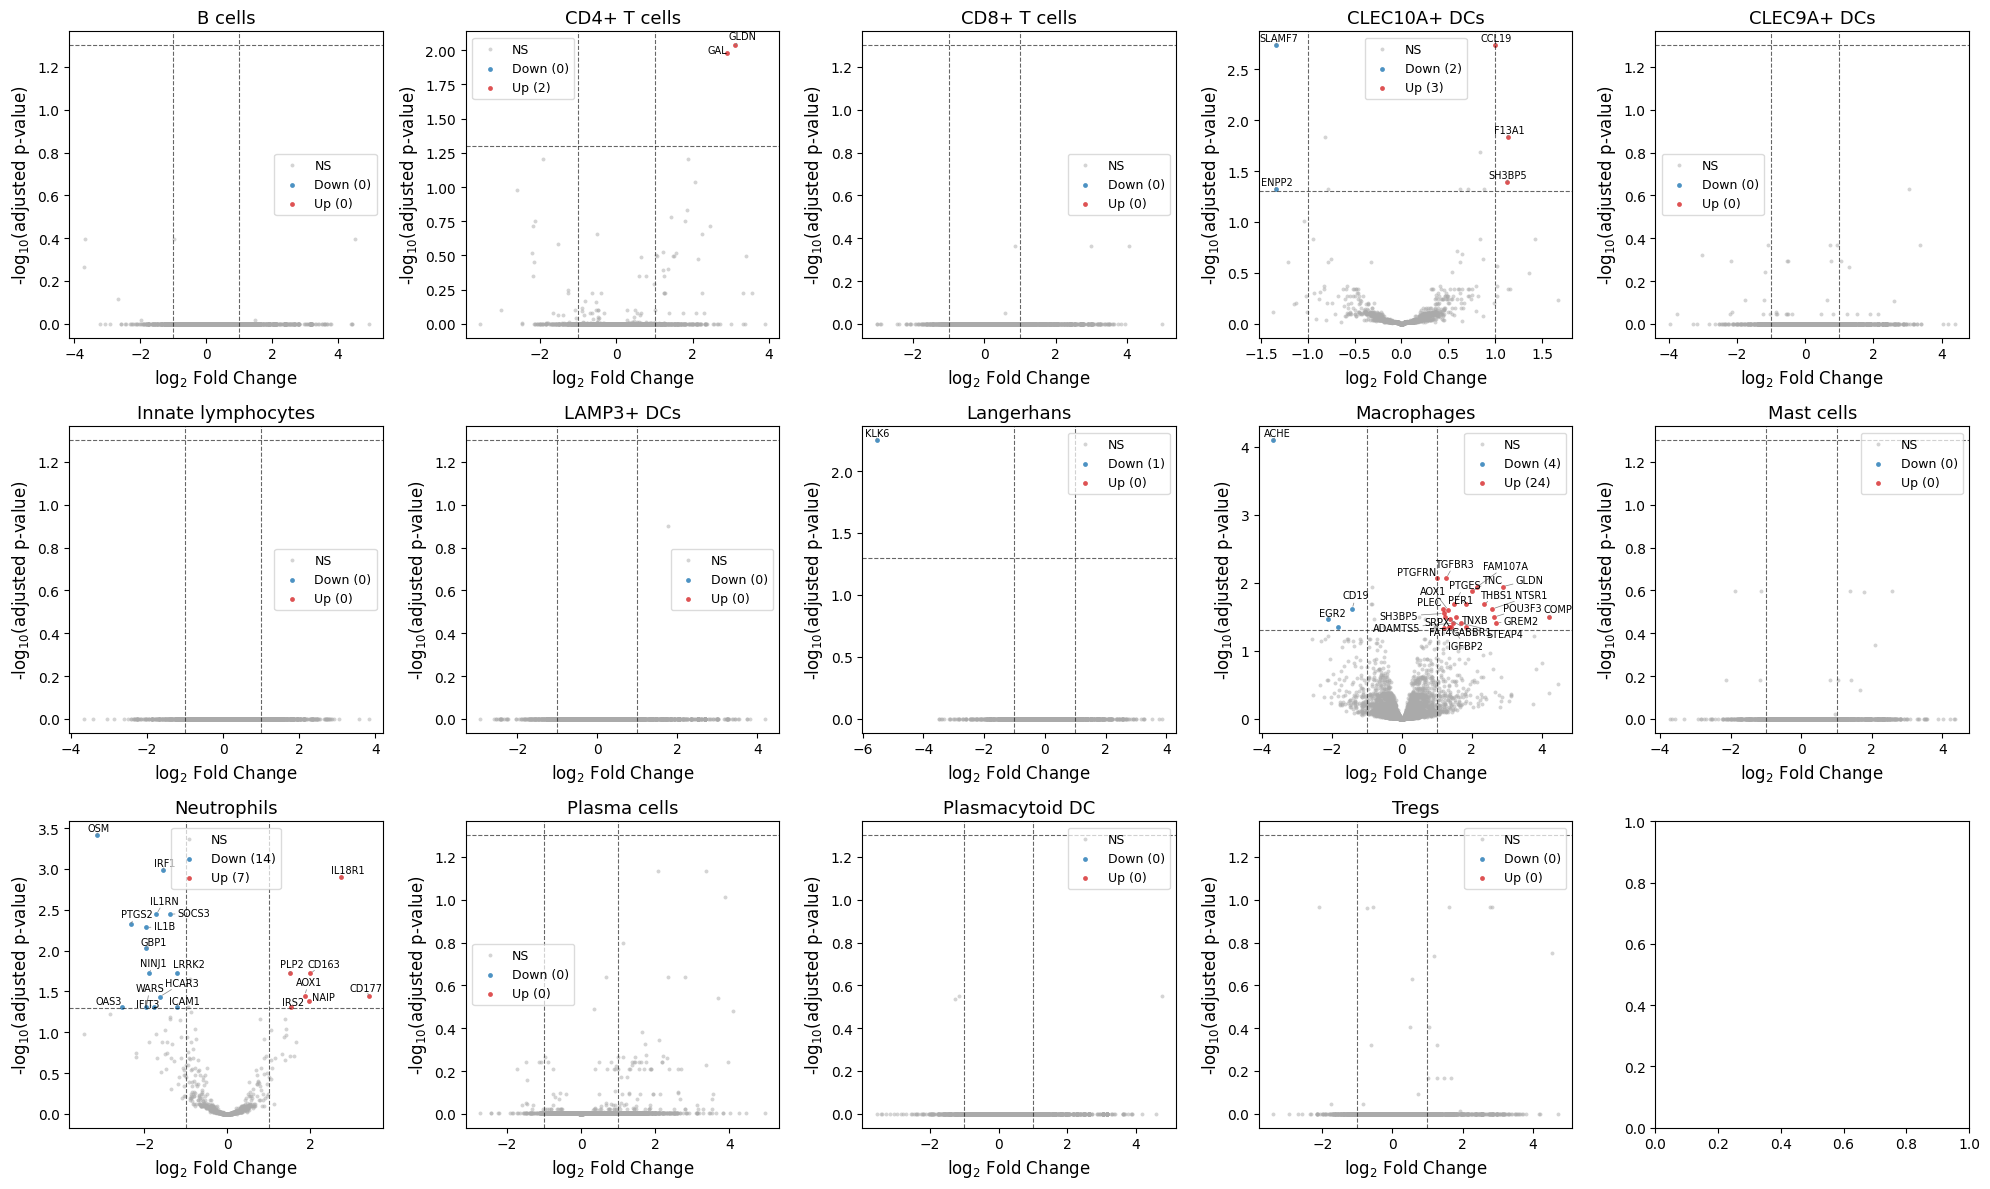

In [90]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, ct in enumerate(immune_results['ct'].unique()):
    fig = plot_volcano(immune_results[immune_results['ct'] == ct], title=ct, top_n_labels=25, ax=axes[i])

plt.show()

## Combine results

In [112]:
contrast[2] + ' vs ' + contrast[1]

'NL vs RMC_EPD'

In [115]:
all_results_df_list = []
for contrast, df in all_results.items():
    df['contrast'] = contrast[2] + ' vs ' + contrast[1]
    all_results_df_list.append(df)

all_results_df = pd.concat(all_results_df_list, ignore_index=True)
all_results_df.to_csv('./output/rmc_diffex_results.csv', index=False)

# JAK/STATs

In [70]:
transcripts = adata_rmc.var_names.to_list()

jaks = [t for t in transcripts if "JAK" in t]
stats = [t for t in transcripts if "STAT" in t]

In [118]:
all_results_df[all_results_df['gene'].isin(jaks+stats)]

,ct,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,sig,direction,contrast
387,Basal KCs,1532.182865,1.006434,0.223407,4.504944,0.000007,0.000072,STAT3,True,up,NL vs RMC_EPD
1012,Basal KCs,1141.592379,1.161948,0.377066,3.081551,0.002059,0.008576,STAT1,True,up,NL vs RMC_EPD
1533,Basal KCs,11.271554,1.511861,0.646035,2.340217,0.019273,0.053006,JAK3,False,up,NL vs RMC_EPD
2209,Basal KCs,1468.567857,0.306542,0.188023,1.630337,0.103030,0.196376,STAT6,False,up,NL vs RMC_EPD
2263,Basal KCs,6.101632,1.235241,0.781043,1.581526,0.113758,0.211989,STAT4,False,up,NL vs RMC_EPD
...,...,...,...,...,...,...,...,...,...,...,...
385965,Vascular ECs,367.783928,0.171597,0.118033,1.453809,0.145999,0.756109,STAT6,False,up,NL_EPD vs RMC_EPD
387223,Vascular ECs,104.864043,-0.145440,0.185236,-0.785158,0.432361,0.917817,JAK2,False,down,NL_EPD vs RMC_EPD
387443,Vascular ECs,12.323848,-0.268223,0.384041,-0.698421,0.484914,0.928259,STAT4,False,down,NL_EPD vs RMC_EPD
389249,Vascular ECs,325.863267,-0.023020,0.183576,-0.125400,0.900207,0.994260,JAK1,False,down,NL_EPD vs RMC_EPD


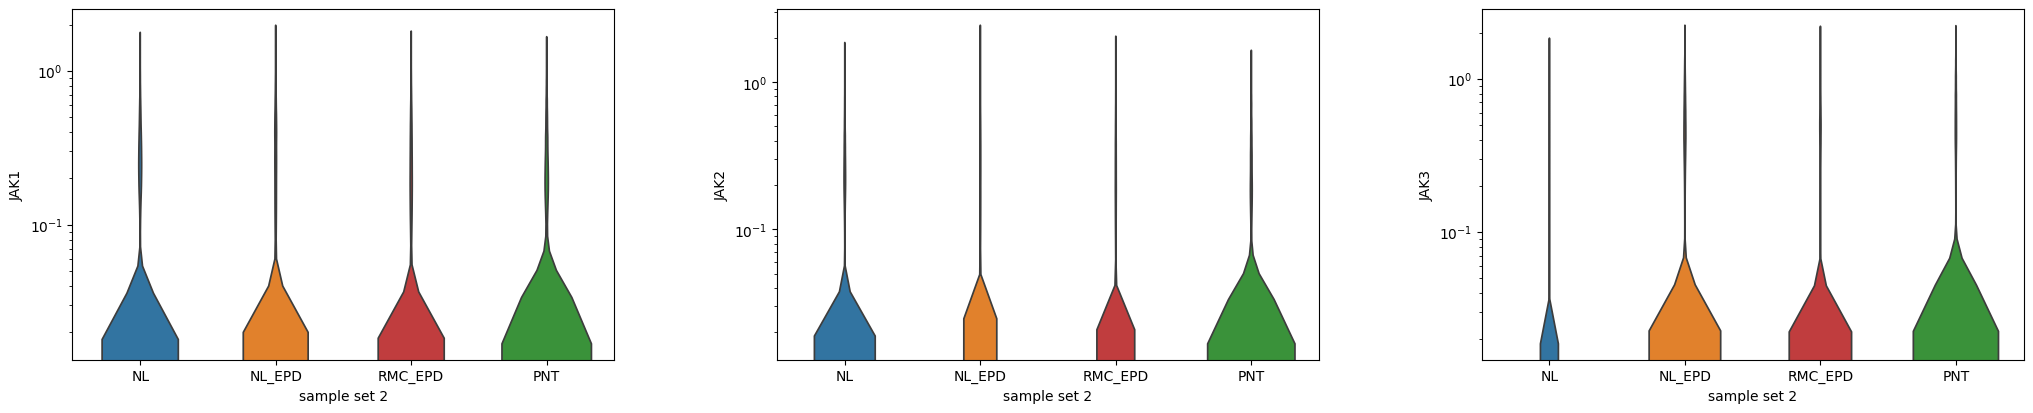

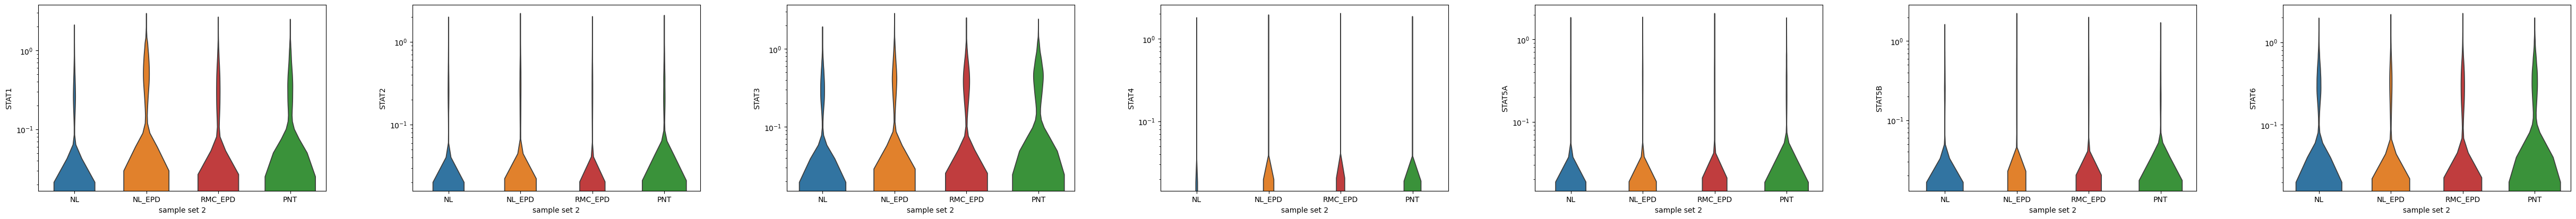

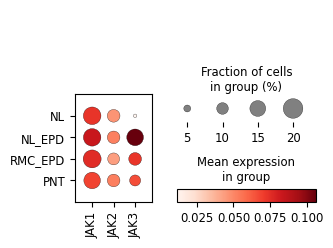

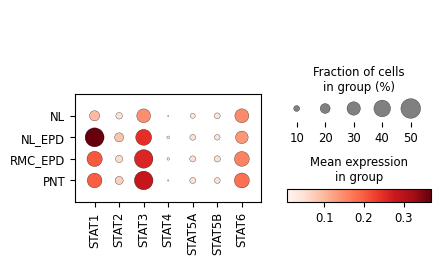

In [71]:
order = ['NL','NL_EPD','RMC_EPD','PNT']

sc.pl.violin(adata_rmc, jaks, groupby='sample_set_2', log=True, stripplot=False, order=order) 
sc.pl.violin(adata_rmc, stats, groupby='sample_set_2', log=True, stripplot=False, order=order) 
sc.pl.dotplot(adata_rmc, var_names=jaks, groupby='sample_set_2', categories_order=order)
sc.pl.dotplot(adata_rmc, var_names=stats, groupby='sample_set_2', categories_order=order)

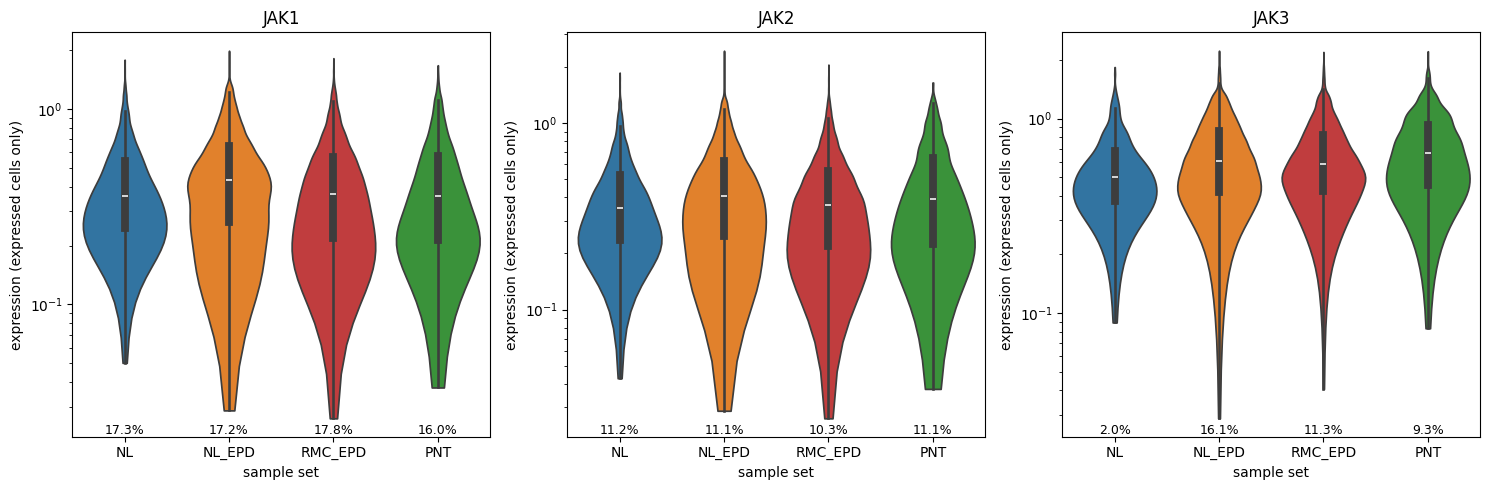

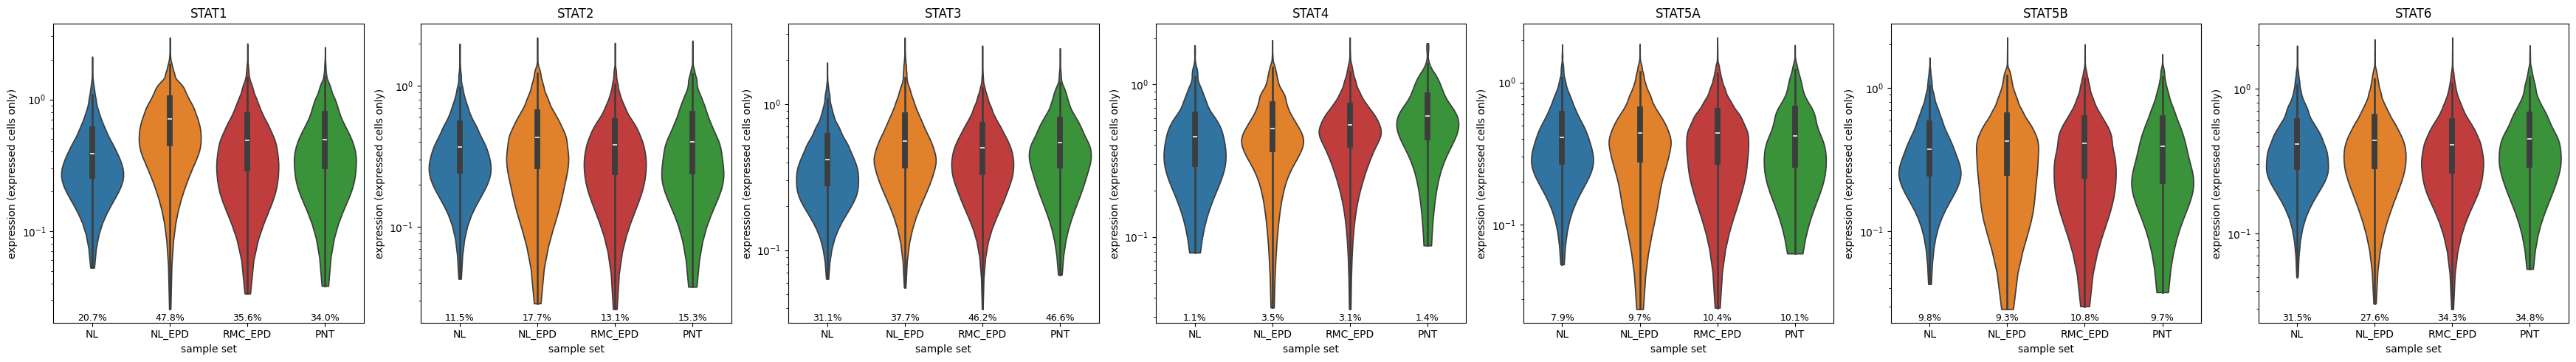

In [13]:
def plot_expression_violins_by_sample_set(
    adata,
    genes,
    groupby,
    *,
    palette=None,
    figsize_per_gene=5,
    fig_height=5,
    inner='box',
    cut=0,
    yscale='log',
    show=True,
    order=None,
):
    """Violin plots of expression by ``sample_set``; violins use expressed cells only (> 0).

    Percent labels are % of all cells in each group with non-zero expression for that gene.
    """
    genes = list(genes)
    if not genes:
        raise ValueError('genes must be a non-empty sequence')

    def _flatten_x(x):
        if hasattr(x, 'toarray'):
            return np.asarray(x.toarray()).ravel()
        return np.asarray(x).ravel()

    rows = []
    sample_groups = adata.obs[groupby]
    for gene in genes:
        expr = _flatten_x(adata[:, gene].X)
        df = pd.DataFrame({'expression': expr, 'sample_set': sample_groups.values})
        df = df[df['expression'] > 0]
        df['gene'] = gene
        rows.append(df)

    plot_df = pd.concat(rows, ignore_index=True)

    n = len(genes)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_gene * n, fig_height), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, gene in zip(axes, genes):
        gene_df = plot_df[plot_df['gene'] == gene]

        if order is None:
            order = sorted(gene_df['sample_set'].dropna().unique())

        sns.violinplot(
            data=gene_df,
            x='sample_set',
            y='expression',
            order=order,
            palette=palette,
            inner=inner,
            cut=cut,
            ax=ax,
        )

        if yscale:
            ax.set_yscale(yscale)
        ax.set_title(gene)
        ax.set_xlabel('sample set')
        ax.set_ylabel('expression (expressed cells only)')

        expr_all = _flatten_x(adata[:, gene].X)
        expressed = expr_all > 0
        obs_groups = adata.obs[groupby].values
        for i, group in enumerate(order):
            mask_group = obs_groups == group
            total = int(mask_group.sum())
            pct = 100.0 * (mask_group & expressed).sum() / total if total else 0.0
            ax.text(i, ax.get_ylim()[0], f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    if show:
        plt.show()
        return
    return fig, axes


palette = dict(zip(adata_rmc.obs['sample_set_2'].cat.categories, adata_rmc.uns['sample_set_2_colors']))
plot_expression_violins_by_sample_set(adata_rmc, jaks, 'sample_set_2', show=True, palette=palette, order=order)
plot_expression_violins_by_sample_set(adata_rmc, stats, 'sample_set_2', show=True, palette=palette, order=order)

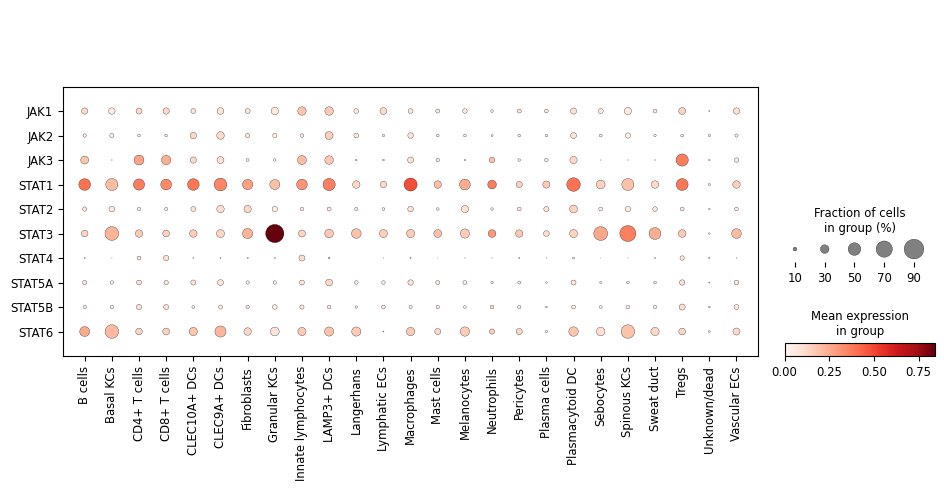

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


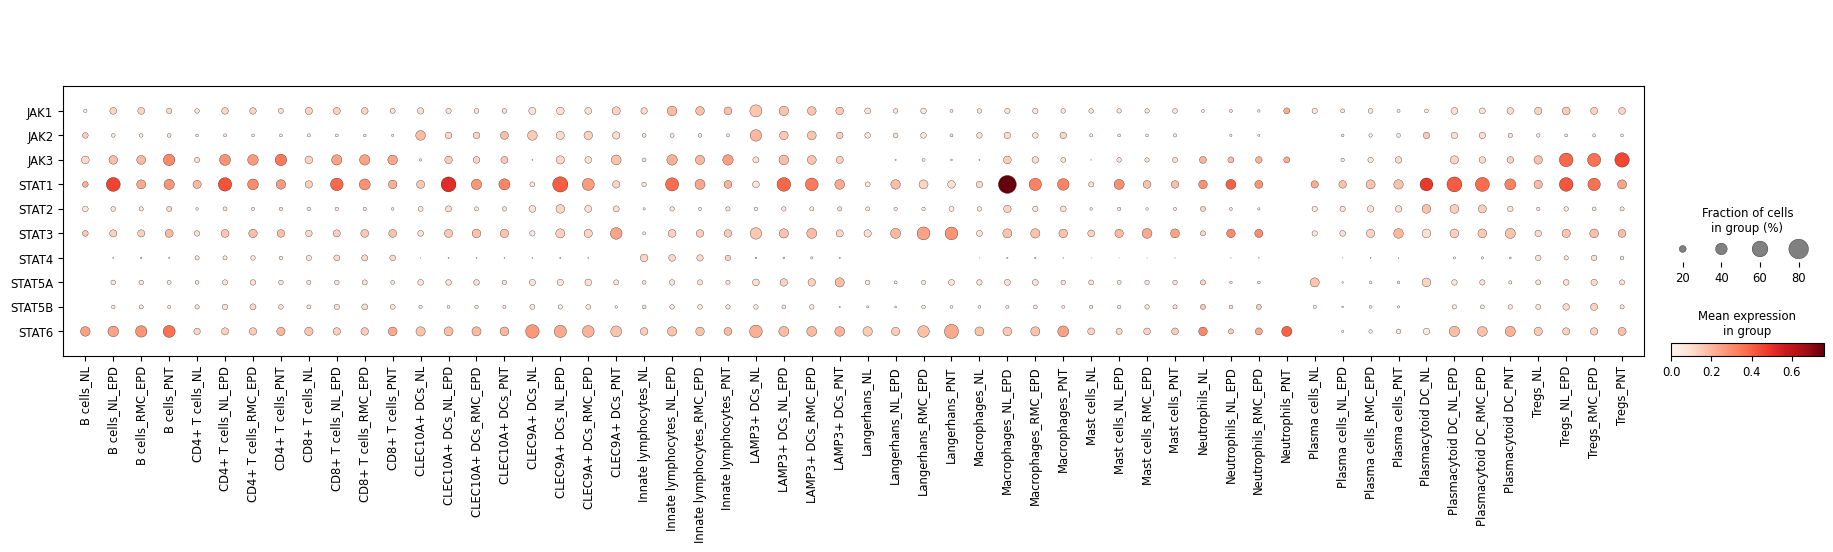

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


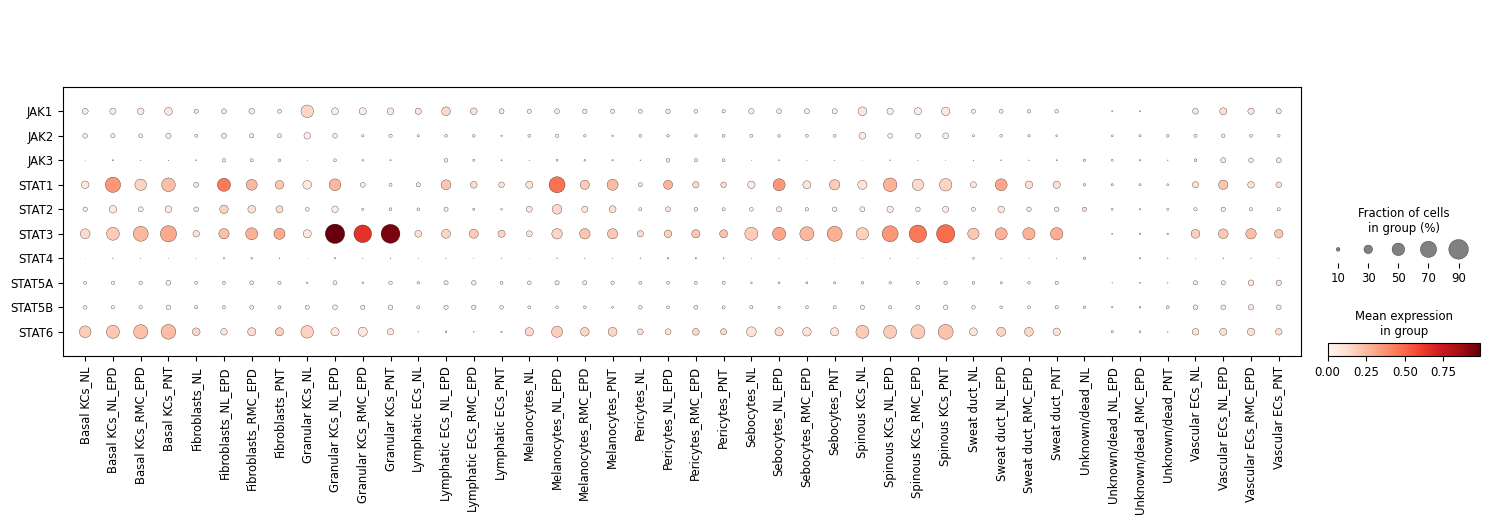

In [106]:
sc.pl.dotplot(adata_rmc, var_names=jaks+stats, groupby=['ct_detailed'], swap_axes=True)

sample_order = ['NL', 'NL_EPD', 'RMC_EPD', 'PNT']  

adata = adata_rmc[adata_rmc.obs['ct_general'] == 'Immune'].copy()
ct_order = adata.obs['ct_detailed'].cat.categories.tolist()
combined_cats = set(adata.obs['ct_detailed'].astype(str) + '_' + adata.obs['sample_set_2'].astype(str)                                                                      ) 
categories_order = [
      f"{ct}_{s}"                                                                                                                                                           
      for ct in ct_order                                    
      for s in sample_order
      if f"{ct}_{s}" in combined_cats
  ]
sc.pl.dotplot(adata, var_names=jaks+stats, groupby=['ct_detailed','sample_set_2'], swap_axes=True, categories_order=categories_order, var_group_rotation=90)


adata = adata_rmc[adata_rmc.obs['ct_general'] != 'Immune'].copy()
ct_order = adata.obs['ct_detailed'].cat.categories.tolist()
combined_cats = set(adata.obs['ct_detailed'].astype(str) + '_' + adata.obs['sample_set_2'].astype(str)                                                                      ) 
categories_order = [
      f"{ct}_{s}"                                                                                                                                                           
      for ct in ct_order                                    
      for s in sample_order
      if f"{ct}_{s}" in combined_cats
  ]
sc.pl.dotplot(adata, var_names=jaks+stats, groupby=['ct_detailed','sample_set_2'], swap_axes=True, categories_order=categories_order)